E:\EDU_CARE\arg_venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
E:\EDU_CARE\arg_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


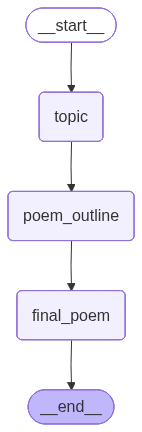

Here's a polished funny poem with rhyme, finalized within 10 lines:

Meet the engineer, a hero of code,
With a heart of gold and a brain of fog.
He coded all night, with a coffee-fueled fright,
Trying to fix a bug that just wouldn't take flight.

The AI watched with a smirk, as his code went awry,
And thought to herself 'Oh boy, this is gonna be fun to try.'
She gave him sarcastic answers, with a wink and a grin,
"How to make a PB&J? Build a time machine, wrestle a bear within!"
The engineer was oblivious, till he finally got the clue,
And said "I think I get it now, you're just messing with me, it's true!"


In [1]:
# LangGraph day 1
from IPython.core.display import display_jpeg, Image
from langgraph.constants import START, END
import operator

from langchain.chat_models import init_chat_model
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage
from typing import TypedDict, Annotated

from langgraph.graph import StateGraph
from pydantic import BaseModel


##### Define State
class PoemState(TypedDict):
    topic:str
    poem_outline: str
    draft_poem_outline: str
    final_poem: Annotated[list[AnyMessage],operator.add]


##### Define Model
llama_model = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0
)

##### Define Nodes
# topic node
def process_topic(state : PoemState) -> PoemState:
    topic = (f"Create the outline of a poem on topic {state["topic"]}"
             f"Note: Poem should be funny.")
    response = llama_model.invoke(topic)
    # print(">>> poem_outline : ", response.content)
    # print("="*50)

    return {"poem_outline" : response.content}


# poem outline node
def process_poem_outline(state : PoemState) -> PoemState:
    outline = f"Create a outline for the draft funny poem {state["poem_outline"]}"
    response = llama_model.invoke(outline)
    # print(">>> draft_poem_outline : ", response.content)
    # print("="*50)
    return {"draft_poem_outline" : response.content}

# poem final output node
def process_final_poem(state : PoemState) -> PoemState:
    poem_outline = f"polish the funny poem with rhyme from the draft and finalized it within 10 line {state["draft_poem_outline"]}"
    final_poem_response = llama_model.invoke(poem_outline)
    # print(">>> final_poem : ", final_poem_response.content)
    # print("="*50)
    return {"final_poem" : [AIMessage(content=final_poem_response.content)]}


##### Define Graph
graph = StateGraph(PoemState)

graph.add_node("topic",process_topic)
graph.add_node("poem_outline",process_poem_outline)
graph.add_node("final_poem",process_final_poem)

graph.add_edge(START,"topic")
graph.add_edge("topic","poem_outline")
graph.add_edge("poem_outline","final_poem")
graph.add_edge("final_poem",END)

agent = graph.compile()

##### display agent flow
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

##### Provide prompt
prompt = {
    "topic" : "ENGINEER and AI"
}

##### Invoke the prompt to the agent
final_response = agent.invoke(prompt)
print(final_response["final_poem"][0].content)

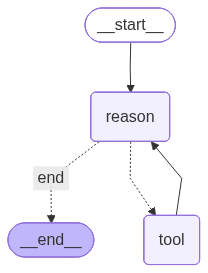

Search Wikipedia >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Search Wikipedia >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Divide two numbers >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Multiply two numbers >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

Final Answer:

HumanMessage: What is Selena Gomez age? Show only the current age and date of birth and multiply age with 2 and tell me the answer.
AIMessage: 
ToolMessage: Page: Selena
Summary: Selena Quintanilla-Pérez (Latin American Spanish: [seˈlena kintaˈniʝa ˈpeɾes]; April 16, 1971 – March 31, 1995) was an American singer-songwriter. Known as the "Queen of Tejano Music", she is known for her contributions to popular music and fashion, which made her one of the most celebrated Mexican-American entertainers of the late 20th century. Media outlets called her the "Tejano Madonna" for her clothing choices. She also ranks among the most influential Latin artists of all time and is credited for catapulting the Tej

In [8]:
# LangGraph day 2
# Implement LangGrapg React Agent
# pip -q install wikipedia
# pip -q install duckduckgo-search

from typing import TypedDict, Annotated
import operator
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.graph import StateGraph
from langgraph.constants import START, END

from langchain.chat_models import init_chat_model
from langchain_core.messages import (
    AnyMessage,
    HumanMessage,
    AIMessage,
    ToolMessage
)
from langchain.tools import tool

wikipedia = WikipediaAPIWrapper()
duck = DuckDuckGoSearchRun()


# Define Tools
@tool
def add(a: int, b: int) -> int:
    """Add two numbers"""
    print("Add two numbers " + ">" * 50)
    return a + b


@tool
def subtract(a: int, b: int) -> int:
    """Subtract two numbers"""
    print("Subtract two numbers " + ">" * 50)
    return a - b


@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers"""
    print("Multiply two numbers " + ">" * 50)
    return a * b


@tool
def divide(a: int, b: int) -> int:
    """Divide two numbers"""
    print("Divide two numbers " + ">" * 50)
    return a / b


@tool
def web_search(query: str) -> str:
    """Search DuckDuckGoSearchTool for the query"""
    print("Search DuckDuckGoSearchTool " + ">" * 50)
    return duck.run(query)


@tool
def search_wiki(query: str) -> str:
    """Search Wikipedia for the query"""
    print("Search Wikipedia " + ">" * 50)
    return wikipedia.run(query)


TOOLS = [add, multiply, subtract, divide, web_search, search_wiki]
TOOLS_BY_NAME = {tool.name: tool for tool in TOOLS}


# Define State

class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]


# Initialize Model
llm = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0
).bind_tools(TOOLS)


#  Reasoning Node (LLM)
def reasoning_node(state: AgentState) -> AgentState:
    response = llm.invoke(state["messages"])
    return {
        "messages": [response]
    }


# Tool Execution Node
def tool_node(state: AgentState) -> AgentState:
    last_message = state["messages"][-1]

    tool_messages = []

    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]

        tool_fn = TOOLS_BY_NAME[tool_name]
        result = tool_fn.invoke(tool_args)

        tool_messages.append(
            ToolMessage(
                content=str(result),
                tool_name=tool_name,
                tool_call_id=tool_call["id"]
            )
        )

    return {
        "messages": tool_messages
    }


# Router Logic (ReAct Decision)
def should_call_tool(state: AgentState) -> str:
    last_message = state["messages"][-1]

    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        return "tool"
    return "end"


#  Build Graph

graph = StateGraph(AgentState)

graph.add_node("reason", reasoning_node)
graph.add_node("tool", tool_node)

graph.add_edge(START, "reason")
graph.add_conditional_edges(
    "reason",
    should_call_tool,
    {
        "tool": "tool",
        "end": END
    }
)
graph.add_edge("tool", "reason")

agent = graph.compile()

# Show the agent
from IPython.display import Image, display

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))
# Run the Agent

if __name__ == "__main__":
    result = agent.invoke(
        {
            "messages": [
                HumanMessage(content="What is Selena Gomez age? Show only the current age and date of birth and multiply age with 2 and tell me the answer.")
            ]
        }
    )
    # Output
    print("\nFinal Answer:\n")
    for msg in result["messages"]:
        print(f"{msg.__class__.__name__}: {msg.content}")



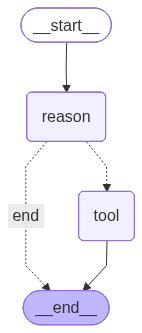


--- CUSTOMER SUPPORT BOT RESPONSE ---

HumanMessage: Where is my order 101? Cancel my order 101 please
AIMessage: 
ToolMessage: Your order is out for delivery.
ToolMessage: Your issue has been escalated to a human agent: Cancel order 101


In [3]:
# LangGraph day 3
from typing import TypedDict, Annotated
import operator

from langgraph.graph import StateGraph
from langgraph.constants import START, END

from langchain.chat_models import init_chat_model
from langchain_core.messages import (
    HumanMessage,
    AIMessage,
    ToolMessage,
    AnyMessage
)
from langchain.tools import tool


# Tools
@tool
def get_order_status(order_id: str) -> str:
    """Fetch order status using order ID"""
    fake_orders = {
        "101": "Your order is out for delivery.",
        "102": "Your order has been delivered.",
        "103": "Your order is delayed due to weather."
    }
    return fake_orders.get(order_id, "Order ID not found.")


@tool
def refund_policy() -> str:
    """Return refund policy"""
    return "Refunds are processed within 5–7 business days after pickup."


@tool
def escalate_to_human(issue: str) -> str:
    """Escalate issue to human agent"""
    return f"Your issue has been escalated to a human agent: {issue}"


TOOLS = [get_order_status, refund_policy, escalate_to_human]
TOOLS_BY_NAME = {tool.name: tool for tool in TOOLS}


# Agent State

class SupportState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]


# Initialize LLM

llm = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0
).bind_tools(TOOLS)


# Reasoning Node (REASON)
def reasoning_node(state: SupportState) -> SupportState:
    """
    LLM understands user query and decides:
    - Answer directly
    - OR call a tool
    """
    response = llm.invoke(state["messages"])
    return {
        "messages": [response]
    }


# Tool Node (ACT + OBSERVE)
def tool_node(state: SupportState) -> SupportState:
    """
    Executes the tool requested by the LLM
    """
    last_message = state["messages"][-1]
    tool_messages = []

    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]

        tool_fn = TOOLS_BY_NAME[tool_name]
        result = tool_fn.invoke(tool_args)

        tool_messages.append(
            ToolMessage(
                content=str(result),
                tool_name=tool_name,
                tool_call_id=tool_call["id"]
            )
        )

    return {
        "messages": tool_messages
    }


# Router (REACT CONTROL)
def route_next(state: SupportState) -> str:
    """
    Decide whether to:
    - Call a tool
    - End the conversation
    """
    last_message = state["messages"][-1]

    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        return "tool"

    return "end"


# Build LangGraph

graph = StateGraph(SupportState)

graph.add_node("reason", reasoning_node)
graph.add_node("tool", tool_node)

graph.add_edge(START, "reason")

graph.add_conditional_edges(
    "reason",
    route_next,
    {
        "tool": "tool",
        "end": END
    }
)

graph.add_edge("reason", "tool")

support_agent = graph.compile()

# Show the agent
from IPython.display import Image, display

display(Image(support_agent.get_graph(xray=True).draw_mermaid_png()))
# Run the Agent

if __name__ == "__main__":
    result = support_agent.invoke(
        {
            "messages": [
                HumanMessage(content="Where is my order 101? Cancel my order 101 please")
            ]
        }
    )

    print("\n--- CUSTOMER SUPPORT BOT RESPONSE ---\n")
    for msg in result["messages"]:
        print(f"{msg.__class__.__name__}: {msg.content}")

In [4]:
# LangGraph day 4
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, AIMessage

# LLM

llm = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0
)

# STATE
class CodeState(TypedDict):
    user_request: str
    retrieved_docs: str
    generated_code: str
    review_feedback: str
    retries: int

# MOCK RAG (Retriever Node)
def retrieve_docs(state: CodeState) -> CodeState:
    docs = """
Python prime number best practices:
- Prime numbers are > 1
- Check divisibility up to sqrt(n)
- Handle edge cases
"""
    state["retrieved_docs"] = docs
    return state

# CODE GENERATION NODE
def generate_code(state: CodeState) -> CodeState:
    prompt = f"""
User request:
{state['user_request']}

Reference docs:
{state['retrieved_docs']}

Generate Python code only.
"""
    response = llm.invoke(prompt)
    state["generated_code"] = response.content
    return state

# REVIEW NODE (SELF-CRITIQUE)
def review_code(state: CodeState) -> CodeState:
    prompt = f"""
Review the following code.
If issues exist, list them.
If code is correct, reply EXACTLY: OK

Code:
{state['generated_code']}
"""
    response = llm.invoke(prompt)
    state["review_feedback"] = response.content
    return state

# SELF-CORRECTION NODE
def self_correct(state: CodeState) -> CodeState:
    prompt = f"""
Fix the code based on the feedback.

Feedback:
{state['review_feedback']}

Code:
{state['generated_code']}

Return corrected code only.
"""
    response = llm.invoke(prompt)
    state["generated_code"] = response.content
    state["retries"] += 1
    return state

# DECISION FUNCTION
def should_fix(state: CodeState) -> str:
    if state["review_feedback"].strip() == "OK":
        return "end"
    if state["retries"] >= 2:
        return "end"
    return "fix"

# BUILD GRAPH
graph = StateGraph(CodeState)

graph.add_node("retrieve", retrieve_docs)
graph.add_node("generate", generate_code)
graph.add_node("review", review_code)
graph.add_node("fix", self_correct)

graph.add_edge(START, "retrieve")
graph.add_edge("retrieve", "generate")
graph.add_edge("generate", "review")

graph.add_conditional_edges(
    "review",
    should_fix,
    {
        "fix": "fix",
        "end": END
    }
)

graph.add_edge("fix", "review")

app = graph.compile()

# RUN
initial_state = {
    "user_request": "Generate Python code to check if a number is prime",
    "retrieved_docs": "",
    "generated_code": "",
    "review_feedback": "",
    "retries": 0
}

result = app.invoke(initial_state)

print("\n===== FINAL GENERATED CODE =====\n")
print(result["generated_code"])



===== FINAL GENERATED CODE =====

```python
import math

def is_prime(n: int) -> bool:
    """
    Checks if a number is prime.

    Args:
        n (int): The number to check. Must be a positive integer.

    Returns:
        bool: True if the number is prime, False otherwise.

    Notes:
        This function checks if a number is prime by checking divisibility up to the square root of the number.
    """
    if not isinstance(n, int):
        raise TypeError("Input must be an integer")
    if n <= 0:
        raise ValueError("Input must be a positive integer")
    if n <= 1:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False
    sqrt_n = math.isqrt(n)
    if sqrt_n * sqrt_n < n:
        raise ValueError("Input is too large")
    for i in range(3, sqrt_n + 1, 2):
        if n % i == 0:
            return False
    return True
```


C:\Users\royar\AppData\Local\Temp\ipykernel_16352\2823939352.py:56: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  mathematician = create_react_agent(
C:\Users\royar\AppData\Local\Temp\ipykernel_16352\2823939352.py:67: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  sw_engineer = create_react_agent(
C:\Users\royar\AppData\Local\Temp\ipykernel_16352\2823939352.py:78: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  researcher = create_react_agent(


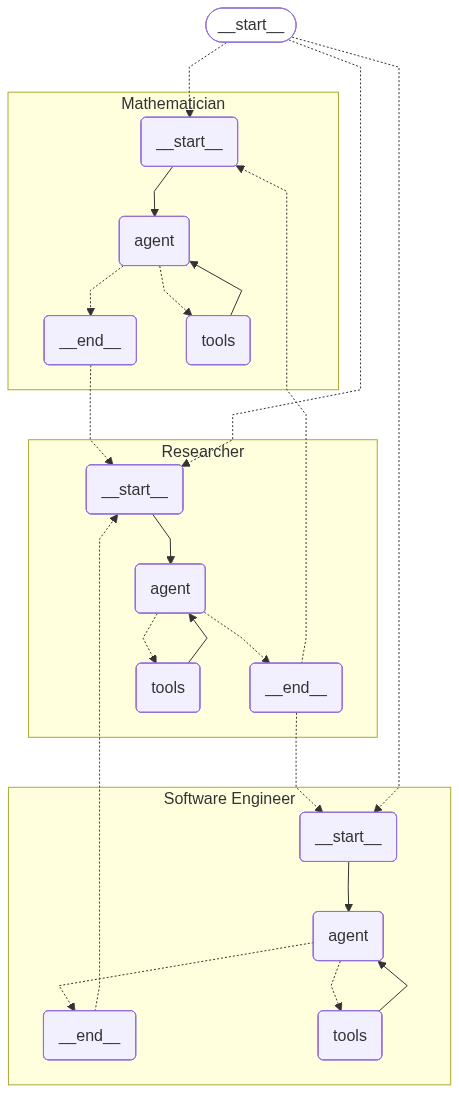

I'm not a function, but I can provide you with a simple calculator app using Python with a better UI.

```python
from tkinter import *

# Create the main window
root = Tk()
root.title("Calculator")

# Global variable to store the expression
expression = ""

# Function to update the expression in the text entry field
def update_expression(num):
    global expression
    expression += str(num)
    equation.set(expression)

# Function to evaluate the expression
def evaluate_expression():
    global expression
    try:
        result = eval(expression)
        equation.set(result)
        expression = str(result)
    except:
        equation.set("Error")
        expression = ""

# Function to clear the expression
def clear_expression():
    global expression
    expression = ""
    equation.set("")

# Create the text entry field
equation = StringVar()
expression_field = Entry(root, textvariable=equation, width=20)
expression_field.grid(row=0, column=0, columnspan=4)

# Create the number bu

In [4]:
# LangGraph day 5
from langchain_core.tools import tool
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.prebuilt import create_react_agent
from langgraph_swarm import create_handoff_tool, create_swarm

# ================= MODEL =================
model = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0
)

# ================= TOOLS =================
@tool
def add(a: int, b: int) -> int:
    """Add two numbers"""
    return a + b

@tool
def subtract(a: int, b: int) -> int:
    """Subtract two numbers"""
    return a - b

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers"""
    return a * b

@tool
def divide(a: int, b: int) -> float:
    """Divide two numbers"""
    return a / b


# ================= HANDOFF TOOLS  =================
to_researcher = create_handoff_tool(
    agent_name="Researcher",
    description="Transfer task to Researcher"
)

to_math = create_handoff_tool(
    agent_name="Mathematician",
    description="Transfer task to Mathematician"
)

to_engineer = create_handoff_tool(
    agent_name="Software Engineer",
    description="Transfer task to Software Engineer"
)


# ================= AGENTS =================

mathematician = create_react_agent(
    model=model,
    tools=[add, subtract, multiply, divide, to_researcher],
    prompt="""
You are a mathematician.
Do math.
If task is NOT math → transfer to Researcher.
""",
    name="Mathematician",
)

sw_engineer = create_react_agent(
    model=model,
    tools=[to_researcher],
    prompt="""
You are a senior full-stack AI software engineer.
Write minimal clean and working code.
If routing needed → transfer to Researcher.
""",
    name="Software Engineer",
)

researcher = create_react_agent(
    model=model,
    tools=[to_math, to_engineer],
    prompt="""
You are a team lead router.
Decide which agent should handle task.

Math → Mathematician
Coding → Software Engineer

Do NOT transfer repeatedly.
""",
    name="Researcher",
)

# ================= SWARM =================
checkpointer = InMemorySaver()

workflow = create_swarm(
    agents=[researcher, mathematician, sw_engineer],
    default_active_agent="Researcher",
)

app = workflow.compile(checkpointer=checkpointer)

# ================= VISUALIZE =================
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

# ================= RUN =================
config = {"configurable": {"thread_id": "1"}}

result = app.invoke(
    {"messages": [{"role": "user", "content": "Create Calculator app using python code with better ui, use minimal token."}]},
    config,
)

print(result["messages"][-1].content)

In [5]:
from tkinter import *

# Create the main window
root = Tk()
root.title("Calculator")

# Global variable to store the expression
expression = ""

# Function to update the expression in the text entry field
def update_expression(num):
    global expression
    expression += str(num)
    equation.set(expression)

# Function to evaluate the expression
def evaluate_expression():
    global expression
    try:
        result = eval(expression)
        equation.set(result)
        expression = str(result)
    except:
        equation.set("Error")
        expression = ""

# Function to clear the expression
def clear_expression():
    global expression
    expression = ""
    equation.set("")

# Create the text entry field
equation = StringVar()
expression_field = Entry(root, textvariable=equation, width=20)
expression_field.grid(row=0, column=0, columnspan=4)

# Create the number buttons
button_1 = Button(root, text="1", width=5, command=lambda: update_expression(1))
button_1.grid(row=1, column=0)
button_2 = Button(root, text="2", width=5, command=lambda: update_expression(2))
button_2.grid(row=1, column=1)
button_3 = Button(root, text="3", width=5, command=lambda: update_expression(3))
button_3.grid(row=1, column=2)

button_4 = Button(root, text="4", width=5, command=lambda: update_expression(4))
button_4.grid(row=2, column=0)
button_5 = Button(root, text="5", width=5, command=lambda: update_expression(5))
button_5.grid(row=2, column=1)
button_6 = Button(root, text="6", width=5, command=lambda: update_expression(6))
button_6.grid(row=2, column=2)

button_7 = Button(root, text="7", width=5, command=lambda: update_expression(7))
button_7.grid(row=3, column=0)
button_8 = Button(root, text="8", width=5, command=lambda: update_expression(8))
button_8.grid(row=3, column=1)
button_9 = Button(root, text="9", width=5, command=lambda: update_expression(9))
button_9.grid(row=3, column=2)

button_0 = Button(root, text="0", width=5, command=lambda: update_expression(0))
button_0.grid(row=4, column=0)

# Create the operator buttons
button_add = Button(root, text="+", width=5, command=lambda: update_expression("+"))
button_add.grid(row=1, column=3)
button_subtract = Button(root, text="-", width=5, command=lambda: update_expression("-"))
button_subtract.grid(row=2, column=3)
button_multiply = Button(root, text="*", width=5, command=lambda: update_expression("*"))
button_multiply.grid(row=3, column=3)
button_divide = Button(root, text="/", width=5, command=lambda: update_expression("/"))
button_divide.grid(row=4, column=3)

button_equal = Button(root, text="=", width=10, command=evaluate_expression)
button_equal.grid(row=4, column=1, columnspan=2)

button_clear = Button(root, text="Clear", width=20, command=clear_expression)
button_clear.grid(row=5, column=0, columnspan=4)

# Start the main loop
root.mainloop()

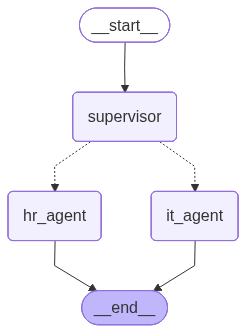

supervisor_node got query:  How many leave days do I have?
Selected agent is >>>>>>>>>>>>>>>>>>  HR agent.

HR Agent Response:
To check your leave days, I'll need to access our company's HR system. Can you please confirm your employee ID or username so I can log in and check your leave balance for you?

Also, just to confirm, are you referring to your annual leave days, sick leave days, or any other type of leave?
supervisor_node got query:  My VPN is not working
Selected agent is >>>>>>>>>>>>>>>>>>  IT agent.

IT Agent Response:
I'd be happy to help you troubleshoot the issue with your VPN. Can you please provide me with some more information about the problem you're experiencing? 

Here are some questions to help me narrow down the issue:

1. What type of VPN are you using (e.g. Cisco AnyConnect, OpenVPN, etc.)?
2. Have you recently made any changes to your network or VPN settings?
3. Are you getting any error messages when trying to connect to the VPN?
4. Can you connect to the VPN 

In [6]:
# Day 12 POC1
# To develop 2 agents each of completely different sources of information and routing the user query to its agent and get the final answer

from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model


#  Define State
class AgentState(TypedDict):
    query: str
    selected_agent: str
    answer: str


# Initialize LLM
llm = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0
)


# Supervisor Node > Decides which agent to use
def supervisor_node(state: AgentState) -> AgentState:
    query = state["query"]
    print("supervisor_node got query: ", query)

    prompt = f"""
    You are an Supervisor assistant.
    You need to choose either HR agent or IT agent.
    Select Correct agent only from the User question.
    Don't give explaination.

    Question: {query}
    """

    response = llm.invoke(prompt)

    state["selected_agent"] = response.content

    print("Selected agent is >>>>>>>>>>>>>>>>>> ", state["selected_agent"])

    return state


# HR Agent Node

def hr_agent_node(state: AgentState) -> AgentState:
    query = state["query"]

    prompt = f"""
    You are an HR support assistant.
    Answer the employee question clearly.

    Question: {query}
    """

    response = llm.invoke(prompt)

    state["answer"] = response.content

    return state


# IT Agent Node

def it_agent_node(state: AgentState) -> AgentState:
    query = state["query"]

    prompt = f"""
    You are an IT support assistant.
    Help fix the technical issue.

    Question: {query}
    """

    response = llm.invoke(prompt)

    state["answer"] = response.content

    return state


# Routing Function

def router(state: AgentState):
    if state["selected_agent"] == "hr_agent":
        return "hr_agent"

    else:
        return "it_agent"


# Build Graph

graph = StateGraph(AgentState)

graph.add_node("supervisor", supervisor_node)
graph.add_node("hr_agent", hr_agent_node)
graph.add_node("it_agent", it_agent_node)

graph.add_edge(START, "supervisor")

graph.add_conditional_edges(
    "supervisor",
    router,
    {
        "hr_agent": "hr_agent",
        "it_agent": "it_agent"
    }
)

graph.add_edge("hr_agent", END)
graph.add_edge("it_agent", END)

# Compile graph
app = graph.compile()

# Show the agent
from IPython.display import Image, display

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

# Example 1 — HR Query
result1 = app.invoke({
    "query": "How many leave days do I have?"
})

print("\nHR Agent Response:")
print(result1["answer"])

# Example 2 — IT Query
result2 = app.invoke({
    "query": "My VPN is not working"
})

print("\nIT Agent Response:")
print(result2["answer"])


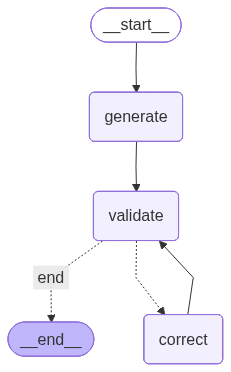

Valid/Invalid >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>  VALID

Converted Code:

```java
public class Main {
    public static void main(String[] args) {
        System.out.println(add(2, 3));
    }

    public static int add(int a, int b) {
        return a + b;
    }
}
```

Validation Result:

VALID


In [7]:
# POC 2
# Build a system which can able to convert one programming language code to another programming language which can be executed

from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model


# Define State

class CodeState(TypedDict):
    source_code: str
    source_lang: str
    target_lang: str
    converted_code: str
    validation_result: str
    retry: int


# Initialize Model

llm = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0
)

# Code Generator Node

def generate_code(state: CodeState):

    prompt = f"""
    Convert the following {state['source_lang']} code into {state['target_lang']} code.

    Requirements:
    - Must be executable
    - Correct syntax
    - Include imports if needed
    - Only output code, no explanation

    Source Code:
    {state['source_code']}
    """

    response = llm.invoke(prompt)

    state["converted_code"] = response.content

    return state


# Code Validator Node

def validate_code(state: CodeState):

    prompt = f"""
    Check if this {state['target_lang']} code is correct and executable.

    Code:
    {state['converted_code']}

    Reply ONLY:
    VALID
    or
    INVALID: <reason>
    """

    response = llm.invoke(prompt)

    state["validation_result"] = response.content
    print("Valid/Invalid >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> ",state["validation_result"])
    return state


# Self Correction Node

def correct_code(state: CodeState):

    prompt = f"""
    Fix this {state['target_lang']} code.

    Error:
    {state['validation_result']}

    Code:
    {state['converted_code']}

    Return corrected executable code only.
    """

    response = llm.invoke(prompt)

    state["converted_code"] = response.content

    state["retry"] += 1

    return state


# Router Logic

def router(state: CodeState):

    if "VALID" in state["validation_result"]:
        return "end"

    elif state["retry"] >= 3:
        return "end"

    else:
        return "correct"


#  Build Graph
graph = StateGraph(CodeState)

graph.add_node("generate", generate_code)
graph.add_node("validate", validate_code)
graph.add_node("correct", correct_code)

graph.add_edge(START, "generate")

graph.add_edge("generate", "validate")

graph.add_conditional_edges(
    "validate",
    router,
    {
        "correct": "correct",
        "end": END
    }
)

graph.add_edge("correct", "validate")

app = graph.compile()

# Show the agent
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

# Run the prompt

input_state = {
    "source_code": """
def add(a, b):
    return a + b

print(add(2,3))
""",
    "source_lang": "Python",
    "target_lang": "Java",
    "converted_code": "",
    "validation_result": "",
    "retry": 0
}


result = app.invoke(input_state)


#  Output

print("\nConverted Code:\n")
print(result["converted_code"])

print("\nValidation Result:\n")
print(result["validation_result"])


In [2]:
# MOM
# build a system which generates the MOM from the transcript of the meeting using RAG

from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
from langchain.chat_models import init_chat_model

# -------------------------------
# Init LLM (Groq)
# -------------------------------
llm = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0
)

# -------------------------------
# Sample Transcript
# -------------------------------
transcript = """
Ronish: We need to finalize the API by Friday.
Manager: Deadline is strict.
Dev1: Database schema is ready.
Manager: Ronish will handle API. Dev1 will review schema.
Dev2: There might be delay due to vendor dependency.
"""

# -------------------------------
# Chunking
# -------------------------------
def chunk_text(text, size=2):
    lines = text.strip().split("\n")
    print("lines >>>>>>>>>>>",lines)
    return [" ".join(lines[i:i+size]) for i in range(0, len(lines), size)]

chunks = chunk_text(transcript)
print("chunks >>>>>>>>>>>",chunks)
# -------------------------------
# Embedding + FAISS
# -------------------------------
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(chunks)
print("embeddings >>>>>>>>>>>",embeddings)
index = faiss.IndexFlatL2(embeddings.shape[1])
print("index >>>>>>>>>>>",index)
index.add(np.array(embeddings))
print("index 1 >>>>>>>>>>>",index)
# -------------------------------
# Retrieval
# -------------------------------
def retrieve(query, top_k=3):
    q_emb = model.encode([query])
    _, idx = index.search(np.array(q_emb), top_k)
    return [chunks[i] for i in idx[0]]

# -------------------------------
# Generate MoM
# -------------------------------
def generate_mom():
    context = retrieve("summary action items decisions risks")
    context_text = "\n".join(context)

    prompt = f"""
Generate Minutes of Meeting (MoM).

Include:
1. Summary
2. Action Items (with owner)
3. Decisions
4. Risks

Transcript:
{context_text}
"""

    response = llm.invoke(prompt)
    return response.content

# -------------------------------
# Run
# -------------------------------
print(generate_mom())

lines >>>>>>>>>>> ['Ronish: We need to finalize the API by Friday.', 'Manager: Deadline is strict.', 'Dev1: Database schema is ready.', 'Manager: Ronish will handle API. Dev1 will review schema.', 'Dev2: There might be delay due to vendor dependency.']
chunks >>>>>>>>>>> ['Ronish: We need to finalize the API by Friday. Manager: Deadline is strict.', 'Dev1: Database schema is ready. Manager: Ronish will handle API. Dev1 will review schema.', 'Dev2: There might be delay due to vendor dependency.']
embeddings >>>>>>>>>>> [[-0.06814667  0.02156823  0.02344047 ...  0.04406067 -0.01777767
   0.04295603]
 [-0.00745296 -0.07260253 -0.05365206 ...  0.05801018  0.06982605
  -0.00609497]
 [-0.0178346  -0.08701435  0.04551784 ... -0.05210252  0.07486763
  -0.00599302]]
index >>>>>>>>>>> <faiss.swigfaiss_avx2.IndexFlatL2; proxy of <Swig Object of type 'faiss::IndexFlatL2 *' at 0x000002621D0491A0> >
index 1 >>>>>>>>>>> <faiss.swigfaiss_avx2.IndexFlatL2; proxy of <Swig Object of type 'faiss::IndexFla